# Module 04 — Lyapunov exponents & chaos indicators

Sensitive dependence on initial conditions is *the* signature of chaos: two
trajectories that start infinitesimally close pull apart exponentially fast.
The **Lyapunov spectrum** turns that intuition into numbers — a set of rates
$\lambda_1 \ge \lambda_2 \ge \dots$ measuring the average expansion (or
contraction) along each direction in tangent space. A single positive
exponent is the working definition of chaos. In this module we compute
spectra, read them, turn them into a fractal dimension, and cross-check them
with a family of complementary **chaos indicators** (GALI, the 0–1 test,
expansion entropy) that agree when a system is chaotic and disagree loudly
when it is not.

**You will learn to:**
- Compute the full **Lyapunov spectrum** of a flow or map (method + top-level forms).
- Read the Lorenz `[+, 0, −]` signature and turn it into a **Kaplan–Yorke dimension**.
- Use the fast **`max_lyapunov`** kernel for maps.
- Watch a running estimate **converge** so you trust your integration time.
- Distinguish regular from chaotic motion with **GALI** (Skokos), the
  **0–1 test** (Gottwald–Melbourne), and **expansion entropy** (Hunt–Ott).

*Estimated time: 30 min.*

In [1]:
# Colab/first-run setup: install the workshop stack if tsdynamics is missing.
try:
    import tsdynamics  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "tsdynamics[viz,interactive]==5.3.1", "matplotlib", "plotly", "pandas"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import tsdynamics as ts
print("tsdynamics", ts.__version__)

tsdynamics 5.3.1


## 1. The Lyapunov spectrum of the Lorenz flow

For a $d$-dimensional flow, evolve $d$ orthonormal tangent vectors alongside
the trajectory, periodically re-orthonormalise them (Benettin's algorithm),
and accumulate the average log-growth of each. That gives the ordered spectrum
$\lambda_1 \ge \dots \ge \lambda_d$. For the Lorenz system

$$\dot x = \sigma(y-x),\quad \dot y = x(\rho - z) - y,\quad \dot z = xy - \beta z$$

the textbook answer at the classic parameters is roughly
$\lambda \approx (0.90,\ 0,\ -14.6)$: one **positive** exponent (stretching →
chaos), one **zero** exponent (the flow direction — always present for a
bounded flow), and one strongly **negative** exponent (contraction onto the
attractor). Two equivalent call styles:

In [2]:
lor = ts.Lorenz()

# Pin the same initial condition so the two call styles compute the *same*
# thing (a Lyapunov estimate is IC-independent in the limit, but a finite-time
# run from a *random* IC would print slightly different digits — see §4).
ic = [1.0, 1.0, 1.0]

# Method form on the system object ...
spectrum_method = lor.lyapunov_spectrum(final_time=200.0, dt=0.02, ic=ic)
# ... and the identical top-level functional form.
spectrum_toplevel = ts.lyapunov_spectrum(ts.Lorenz(), final_time=200.0, dt=0.02, ic=ic)

print("method   form:", np.round(np.asarray(spectrum_method), 3))
print("top-level form:", np.round(np.asarray(spectrum_toplevel), 3))
print("\nsum of exponents (≈ divergence −(σ+1+β) = −13.67):",
      round(float(np.sum(spectrum_method)), 2))

method   form: [ 8.9200e-01  4.0000e-03 -1.4563e+01]
top-level form: [ 8.9200e-01  4.0000e-03 -1.4563e+01]

sum of exponents (≈ divergence −(σ+1+β) = −13.67): -13.67


Both forms return the same ordered `ndarray`. The signature is exactly
`[+, 0, −]`. The **sum** of the exponents equals the trace of the flow's
Jacobian averaged over the attractor — for Lorenz that is the constant
$-(\sigma + 1 + \beta) = -13.67$, a nice sanity check that the phase-space
volume contracts (dissipative system).

## 2. From exponents to a fractal dimension: Kaplan–Yorke

The **Kaplan–Yorke** (Lyapunov) dimension interpolates between the number of
expanding directions and the rate of contraction:

$$D_{KY} = k + \frac{\sum_{i=1}^{k}\lambda_i}{|\lambda_{k+1}|},$$

where $k$ is the largest index with a non-negative partial sum. For Lorenz it
lands near $2.06$ — the strange attractor is a *thin fractal sheet*: more than
a 2-D surface, far less than a space-filling 3-D blob.

In [3]:
d_ky = ts.kaplan_yorke_dimension(spectrum_method)
print(f"Kaplan–Yorke dimension of the Lorenz attractor: {float(d_ky):.4f}")
print(f"(compare: correlation dimension D2 ≈ 2.05, measured directly in Module 05)")

Kaplan–Yorke dimension of the Lorenz attractor: 2.0615
(compare: correlation dimension D2 ≈ 2.05, measured directly in Module 05)


`kaplan_yorke_dimension` returns a scalar-like `Result` that prints and
behaves like a float. A value between 2 and 3 is the hallmark of a
low-dimensional strange attractor living in 3-D phase space.

## 3. The fast path for maps: `max_lyapunov`

For a discrete map you often only want the **leading** exponent, and the
library ships a dedicated native QR-tangent kernel for it — far faster and
more robust than a two-trajectory rescaling loop. The Hénon map at its classic
parameters has $\lambda_1 \approx 0.42$; the logistic map at $r=4$ has the
exact value $\lambda = \ln 2 \approx 0.693$ (a rare closed form).

In [4]:
lam_henon = ts.max_lyapunov(ts.Henon(), ic=[0.1, 0.1])
lam_logistic = ts.max_lyapunov(ts.Logistic().with_params(r=4.0), ic=[0.3])

print(f"Hénon         λ₁ ≈ {float(lam_henon):.4f}   (literature 0.419)")
print(f"Logistic r=4  λ₁ ≈ {float(lam_logistic):.4f}   (exact  ln 2 = {np.log(2):.4f})")

Hénon         λ₁ ≈ 0.4216   (literature 0.419)
Logistic r=4  λ₁ ≈ 0.6937   (exact  ln 2 = 0.6931)


Hitting $\ln 2$ to three digits is a good confidence check on the whole
tangent-map machinery. `max_lyapunov` also works on flows (a Benettin
two-trajectory scheme there), but for maps this kernel is the one to reach for.

## 4. Convergence: is my integration time long enough?

A Lyapunov exponent is a *long-time average*. Report it too early and you are
reading transient noise. The honest workflow is to plot the running estimate
against integration time and confirm it has settled. Here we recompute the
leading Lorenz exponent for a sequence of increasing horizons and watch it
relax toward ≈ 0.9.

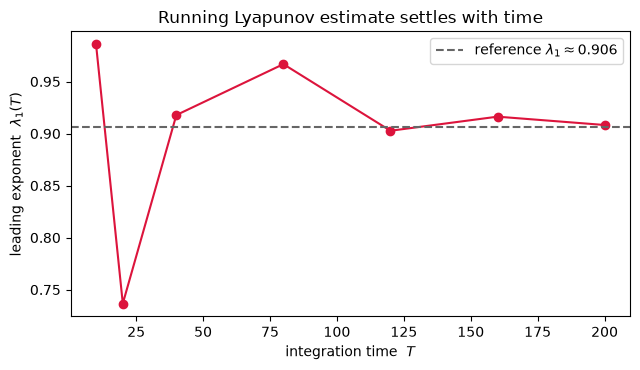

λ₁ vs T: [0.986 0.737 0.918 0.967 0.903 0.916 0.908]


In [5]:
horizons = np.array([10, 20, 40, 80, 120, 160, 200], dtype=float)
leading = np.array([
    float(np.asarray(ts.Lorenz().lyapunov_spectrum(final_time=T, dt=0.02))[0])
    for T in horizons
])

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(horizons, leading, "o-", color="crimson", lw=1.5)
ax.axhline(0.906, ls="--", color="0.4", label=r"reference $\lambda_1 \approx 0.906$")
ax.set_xlabel("integration time  $T$")
ax.set_ylabel(r"leading exponent  $\lambda_1(T)$")
ax.set_title("Running Lyapunov estimate settles with time")
ax.legend()
fig.tight_layout()
plt.show()

print("λ₁ vs T:", np.round(leading, 3))

The estimate wanders for short $T$ and tightens as the trajectory samples more
of the attractor. By $T \approx 150$–$200$ it is stable to a couple of percent
— good enough to *call* the system chaotic. If your curve is still drifting,
integrate longer (or discard a longer transient) before you trust the number.

## 5. Chaos indicator I — GALI (Skokos)

The **Generalised Alignment Index** $\text{GALI}_k$ tracks the volume spanned
by $k$ initially independent tangent vectors (Skokos et al., *Physica D*
2007). For **chaotic** motion the vectors all align with the fastest-growing
direction, so the volume — and $\text{GALI}_k$ — collapses to zero
*exponentially*. For **regular** (quasi-periodic) motion on a torus the
vectors stay spread out, and $\text{GALI}_2$ hovers near a constant. It is one
of the sharpest regular-vs-chaotic discriminators known.

We contrast the chaotic Lorenz flow against a genuinely regular flow: two
uncoupled harmonic oscillators with incommensurate frequencies $1$ and
$\sqrt2$, whose motion lies on a 2-torus. (Defining a custom system uses the
`@staticmethod _equations` / `dim=` / **symengine** contract from Module 02.)

In [6]:
class TwoTorus(ts.ContinuousSystem):
    """Two uncoupled oscillators on a 2-torus — regular, quasi-periodic motion."""
    params = {"w1": 1.0, "w2": float(np.sqrt(2.0))}
    dim = 4
    default_ic = [1.0, 0.0, 1.0, 0.0]

    @staticmethod
    def _equations(y, t, *, w1, w2):
        x1, v1, x2, v2 = y(0), y(1), y(2), y(3)
        return [v1, -w1 * w1 * x1, v2, -w2 * w2 * x2]


gali_regular = ts.gali(TwoTorus(), 2, final_time=60.0, dt=0.05)
gali_chaotic = ts.gali(ts.Lorenz(), 2, final_time=40.0, dt=0.02)

print(f"regular (2-torus)  GALI₂ final = {float(gali_regular.final):.4f}   is_chaotic() = {gali_regular.is_chaotic()}")
print(f"chaotic (Lorenz)   GALI₂ final = {float(gali_chaotic.final):.2e}   is_chaotic() = {gali_chaotic.is_chaotic()}")

regular (2-torus)  GALI₂ final = 0.9999   is_chaotic() = False
chaotic (Lorenz)   GALI₂ final = 0.00e+00   is_chaotic() = True


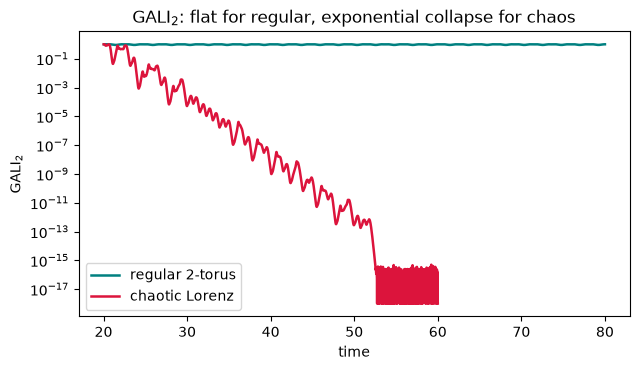

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.semilogy(gali_regular.times, np.clip(gali_regular.values, 1e-18, None),
            color="teal", lw=1.8, label="regular 2-torus")
ax.semilogy(gali_chaotic.times, np.clip(gali_chaotic.values, 1e-18, None),
            color="crimson", lw=1.8, label="chaotic Lorenz")
ax.set_xlabel("time")
ax.set_ylabel(r"$\mathrm{GALI}_2$")
ax.set_title(r"$\mathrm{GALI}_2$: flat for regular, exponential collapse for chaos")
ax.legend()
fig.tight_layout()
plt.show()

The two curves could not be more different: $\text{GALI}_2$ stays pinned near
$1$ for the torus, but plunges to machine zero for Lorenz — an exponential
decay whose rate is set by the gap $\lambda_1 - \lambda_2$. The
`GALIResult.is_chaotic()` verdict reads exactly that behaviour off the curve.

## 6. Chaos indicator II — the 0–1 test (Gottwald–Melbourne)

The **0–1 test** (Gottwald & Melbourne, *SIAM J. Appl. Dyn. Syst.* 2004) needs
only a scalar time series — no tangent vectors, no Jacobian. It drives an
auxiliary translation variable with the signal and measures how its
mean-square displacement grows: **bounded** (regular) gives an output
$K \approx 0$; **diffusive** (chaotic) gives $K \approx 1$. We apply it to the
logistic map at a periodic parameter ($r=3.2$, a stable 2-cycle) and a chaotic
one ($r=4.0$).

In [8]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # silence the harmless random-IC retry chatter
    K_periodic = ts.zero_one_test(ts.Logistic().with_params(r=3.2), component=0, n=4000, transient=1000)
    K_chaotic = ts.zero_one_test(ts.Logistic().with_params(r=4.0), component=0, n=4000, transient=1000)

print(f"Logistic r = 3.2 (period-2):  K = {float(K_periodic.value):+.3f}   → regular")
print(f"Logistic r = 4.0 (chaos)   :  K = {float(K_chaotic.value):+.3f}   → chaotic")

Logistic r = 3.2 (period-2):  K = -0.004   → regular
Logistic r = 4.0 (chaos)   :  K = +0.998   → chaotic


A clean split: $K \approx 0$ for the periodic orbit, $K \approx 1$ for the
chaotic one. Because it works straight off a measured scalar signal, the 0–1
test is the natural bridge to the model-free time-series toolkit in Module 05
— you can run it on real data where you have no equations at all.

## 7. Chaos indicator III — expansion entropy (Hunt–Ott)

**Expansion entropy** $H_0$ (Hunt & Ott, *Chaos* 2015) is a modern,
region-based definition of chaos: sample many initial conditions in a box,
evolve the linearised dynamics, and measure the average exponential growth
rate of an infinitesimal volume. $H_0 > 0$ *is* the definition of chaos, and
for a map it equals the sum of the positive Lyapunov exponents. On the Hénon
map $H_0$ should track its leading exponent $\approx 0.42$; drop Hénon into a
non-chaotic regime and $H_0$ vanishes.

In [9]:
from tsdynamics.data import Box

box = Box(np.array([-1.5, -0.5]), np.array([1.5, 0.5]))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ee_chaotic = ts.expansion_entropy(ts.Henon(), box, n_samples=800, n=14, seed=0)
    ee_regular = ts.expansion_entropy(ts.Henon().with_params(a=0.2, b=0.3),
                                      box, n_samples=800, n=14, seed=0)

print(f"Hénon a=1.4 (chaotic):  H₀ = {float(ee_chaotic.value):+.3f} ± {float(ee_chaotic.stderr):.3f}"
      f"   (its λ₁ ≈ {float(lam_henon):.3f})")
print(f"Hénon a=0.2 (regular):  H₀ = {float(ee_regular.value):+.3f} ± {float(ee_regular.stderr):.3f}")

Hénon a=1.4 (chaotic):  H₀ = +0.462 ± 0.002   (its λ₁ ≈ 0.422)
Hénon a=0.2 (regular):  H₀ = -0.002 ± 0.001


The chaotic Hénon returns $H_0 \approx 0.46$ — within error of its leading
Lyapunov exponent — while the regular one returns $\approx 0$. **Three
independent indicators now agree**: GALI collapses, the 0–1 test reads ≈1, and
expansion entropy is positive exactly when Lyapunov says the system is chaotic.
That convergence of evidence is what makes a chaos diagnosis trustworthy — no
single number should stand alone.

## 🧪 Exercises

Work these top-to-bottom. Fill in each starter cell, then check yourself
against the **Solutions** section at the end.

**Exercise 1 — Spectrum + dimension of the Rössler attractor.**
Compute the full Lyapunov spectrum of `ts.Rossler()` (use `final_time=250`,
`dt=0.05`), confirm it has the `[+, 0, −]` signature, and report its
Kaplan–Yorke dimension. *Hint:* the Rössler attractor is famously "thin" —
expect $D_{KY}$ just above 2.

**Exercise 2 — The fast map exponent.**
Use `ts.max_lyapunov` to get the leading exponent of the **Ikeda** map
(`ts.Ikeda()`, start from `ic=[0.1, 0.1]`). Is it positive (chaotic)?

**Exercise 3 — 0–1 test on a periodic vs chaotic signal.**
Run `ts.zero_one_test` on the Hénon map in a **periodic** regime
(`with_params(a=0.9, b=0.3)`) and in its **chaotic** regime (defaults). Pass
`component=0`. Print both $K$ values and label each. *Hint:* wrap the calls in
`warnings.catch_warnings()` + `simplefilter("ignore")` to hide the random-IC
retry chatter.

**Exercise 4 — Convergence of a map exponent.**
For the logistic map at $r = 3.7$, compute `max_lyapunov` for a growing number
of iterations `n ∈ {50, 100, 200, 400}` (pass `n=` and `ic=[0.3]`) and plot
the estimate vs `n`. Does it settle?

In [10]:
# Exercise 1 — Rössler spectrum + Kaplan–Yorke dimension.
# YOUR CODE HERE

In [11]:
# Exercise 2 — leading exponent of the Ikeda map via max_lyapunov.
# YOUR CODE HERE

In [12]:
# Exercise 3 — 0–1 test: periodic vs chaotic Hénon.
# YOUR CODE HERE

In [13]:
# Exercise 4 — convergence of the logistic-map exponent vs iteration count.
# YOUR CODE HERE

## ✅ Solutions

### Solution 1

In [14]:
ross_spectrum = ts.Rossler().lyapunov_spectrum(final_time=250.0, dt=0.05)
print("Rössler spectrum:", np.round(np.asarray(ross_spectrum), 4))
print("signature [+, 0, −]:",
      np.asarray(ross_spectrum)[0] > 0,
      abs(np.asarray(ross_spectrum)[1]) < 0.05,
      np.asarray(ross_spectrum)[2] < 0)
print(f"Kaplan–Yorke dimension: {float(ts.kaplan_yorke_dimension(ross_spectrum)):.4f}")

Rössler spectrum: [ 8.3600e-02  3.2000e-03 -5.4202e+00]
signature [+, 0, −]: True True True
Kaplan–Yorke dimension: 2.0160


One positive, one near-zero, one strongly negative exponent — chaos, with a
Kaplan–Yorke dimension just above 2. The Rössler attractor is even thinner
than Lorenz's: it is essentially a folded 2-D sheet.

### Solution 2

In [15]:
lam_ikeda = ts.max_lyapunov(ts.Ikeda(), ic=[0.1, 0.1])
print(f"Ikeda map  λ₁ ≈ {float(lam_ikeda):.4f}  →  {'chaotic' if float(lam_ikeda) > 0 else 'regular'}")

Ikeda map  λ₁ ≈ 0.5029  →  chaotic


The Ikeda map has a clearly positive leading exponent — its famous
strange attractor is chaotic.

### Solution 3

In [16]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    K_reg = ts.zero_one_test(ts.Henon().with_params(a=0.9, b=0.3), component=0, n=4000, transient=1000)
    K_cha = ts.zero_one_test(ts.Henon(), component=0, n=4000, transient=1000)

print(f"Hénon a=0.9 (periodic):  K = {float(K_reg.value):+.3f}  → regular")
print(f"Hénon a=1.4 (chaotic) :  K = {float(K_cha.value):+.3f}  → chaotic")

Hénon a=0.9 (periodic):  K = -0.004  → regular
Hénon a=1.4 (chaotic) :  K = +0.997  → chaotic


$K \approx 0$ in the periodic window and $K \approx 1$ in the strange-attractor
regime — the 0–1 test cleanly separates the two straight from the scalar
orbit, matching the Lyapunov verdict.

### Solution 4

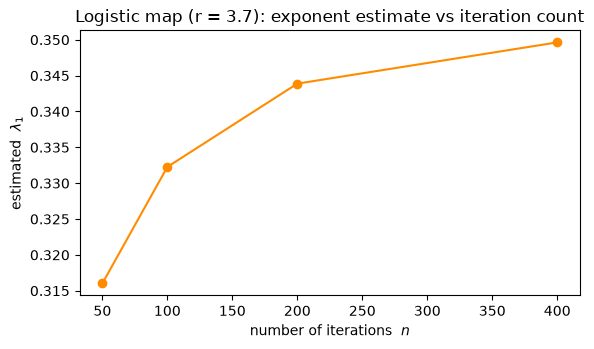

λ₁ vs n: [0.316  0.3323 0.3439 0.3496]


In [17]:
n_iters = np.array([50, 100, 200, 400])
lam_vs_n = np.array([float(ts.max_lyapunov(ts.Logistic().with_params(r=3.7), ic=[0.3], n=int(n)))
                     for n in n_iters])

fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.plot(n_iters, lam_vs_n, "o-", color="darkorange", lw=1.5)
ax.set_xlabel("number of iterations  $n$")
ax.set_ylabel(r"estimated  $\lambda_1$")
ax.set_title("Logistic map (r = 3.7): exponent estimate vs iteration count")
fig.tight_layout()
plt.show()

print("λ₁ vs n:", np.round(lam_vs_n, 4))

The estimate stabilises quickly (maps mix fast) toward a small positive value
— $r = 3.7$ sits in a chaotic band of the logistic map. As with flows, always
confirm the number has stopped drifting before you report it.

## Recap / Where next

You now have a full chaos-quantification toolkit:
- **`lyapunov_spectrum`** — the ordered exponents; `[+, 0, −]` ⇒ chaotic flow.
- **`kaplan_yorke_dimension`** — exponents → fractal dimension of the attractor.
- **`max_lyapunov`** — the fast leading-exponent kernel for maps.
- **Convergence plots** — never trust a Lyapunov number that is still drifting.
- **GALI**, the **0–1 test**, and **expansion entropy** — three independent
  witnesses that agree when (and only when) a system is genuinely chaotic.

Every indicator here needed the *equations*. In **Module 05 —
Nonlinear time-series analysis** we drop that luxury: given only a measured
scalar signal, we reconstruct the attractor by delay embedding and recover the
leading exponent from data with `lyapunov_from_data` — the model-free skills
the capstone's "Guardian of the Grid" leans on when all it has is a sensor
trace.